In [1]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
# =========================
# Load dataset splits
# =========================
DATA_PATH = "../../Datasets/TCGA InfiniumPurify Dataset Splits"

X_train = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_PATH}/X_test.csv")
Y_train = pd.read_csv(f"{DATA_PATH}/Y_train.csv")
Y_test  = pd.read_csv(f"{DATA_PATH}/Y_test.csv")

# Ensure y is 1D
y_train = np.ravel(Y_train)
y_test  = np.ravel(Y_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((494, 19277), (123, 19277), (494,), (123,))


Calculating SHAP values...
SHAP values shape: (123, 100, 5)
Selected features: 100

=== Overall Top 10 Features ===
      Feature  MeanAbsSHAP_MaxAcrossSubtypes
37      LRRC6                       0.021677
13    PA2G4P4                       0.020031
55    MIR1178                       0.019570
6      AXDND1                       0.019342
70     ABCC11                       0.018438
48     ZCCHC8                       0.017419
71  LOC440335                       0.016610
56        CIT                       0.015181
72     SEPT12                       0.013491
99       SUN2                       0.013372


C:\Users\Roooiz\AppData\Local\Temp\ipykernel_2892\3761685964.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


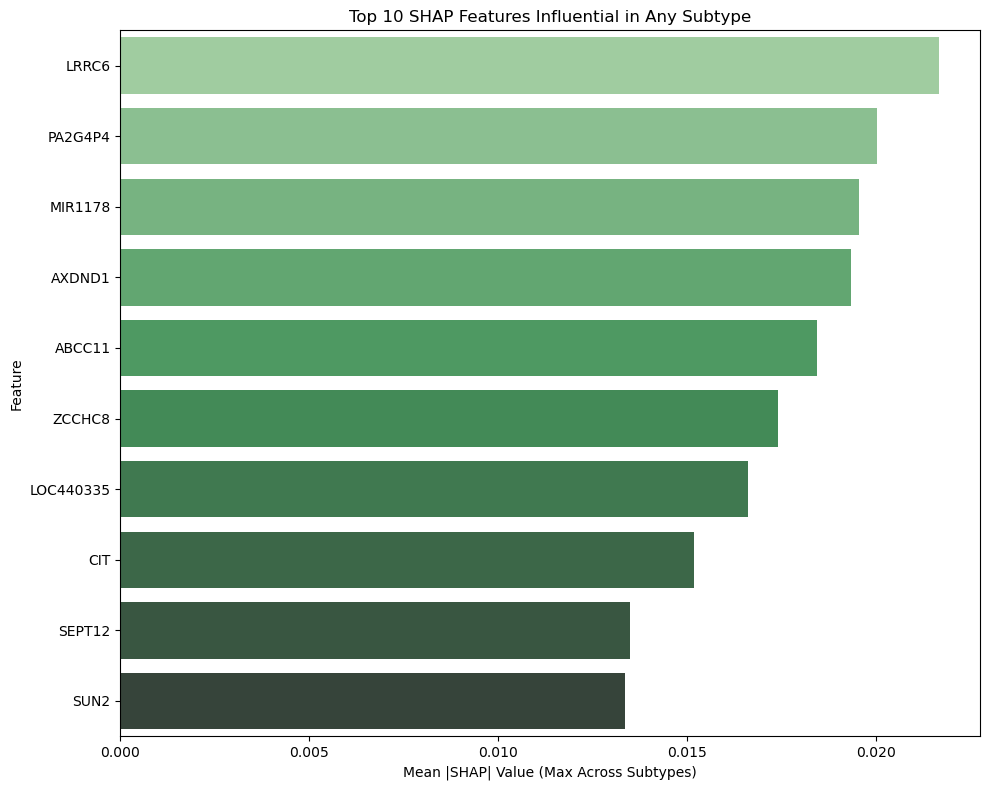

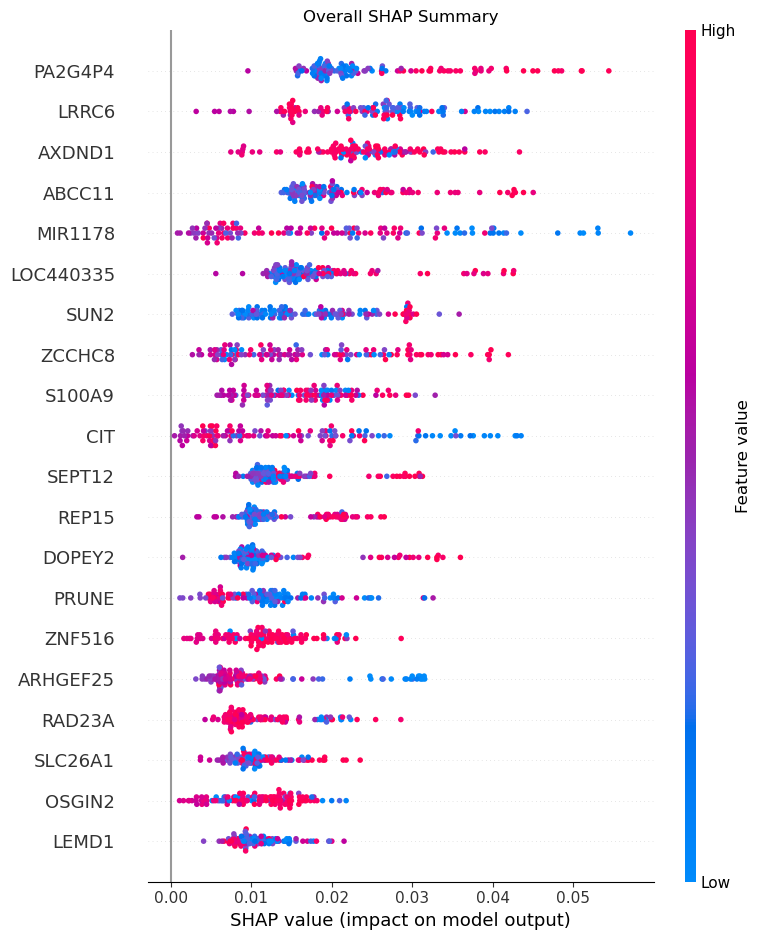


Subtype 1: Basal
      Feature  MeanAbsSHAP
13    PA2G4P4     0.020031
70     ABCC11     0.018438
71  LOC440335     0.016610
6      AXDND1     0.014116
72     SEPT12     0.013491
98     DOPEY2     0.012929
37      LRRC6     0.012659
5      S100A9     0.011112
85     RAD23A     0.010059
57      REP15     0.010050


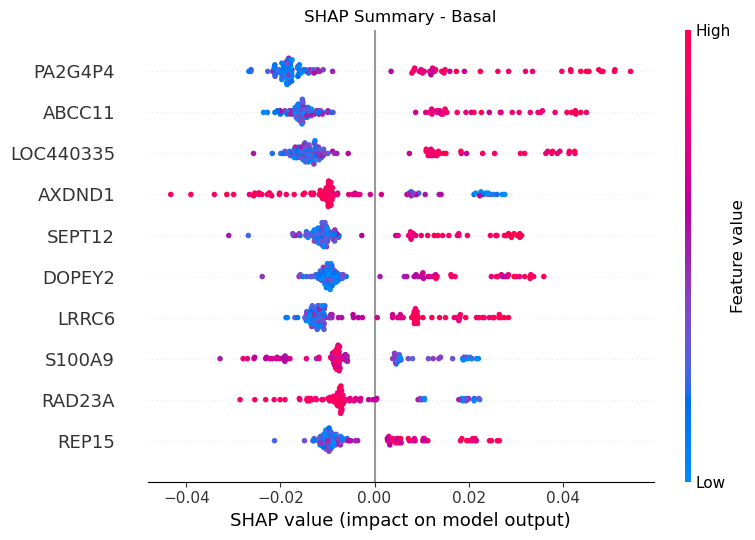

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_2892\3761685964.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


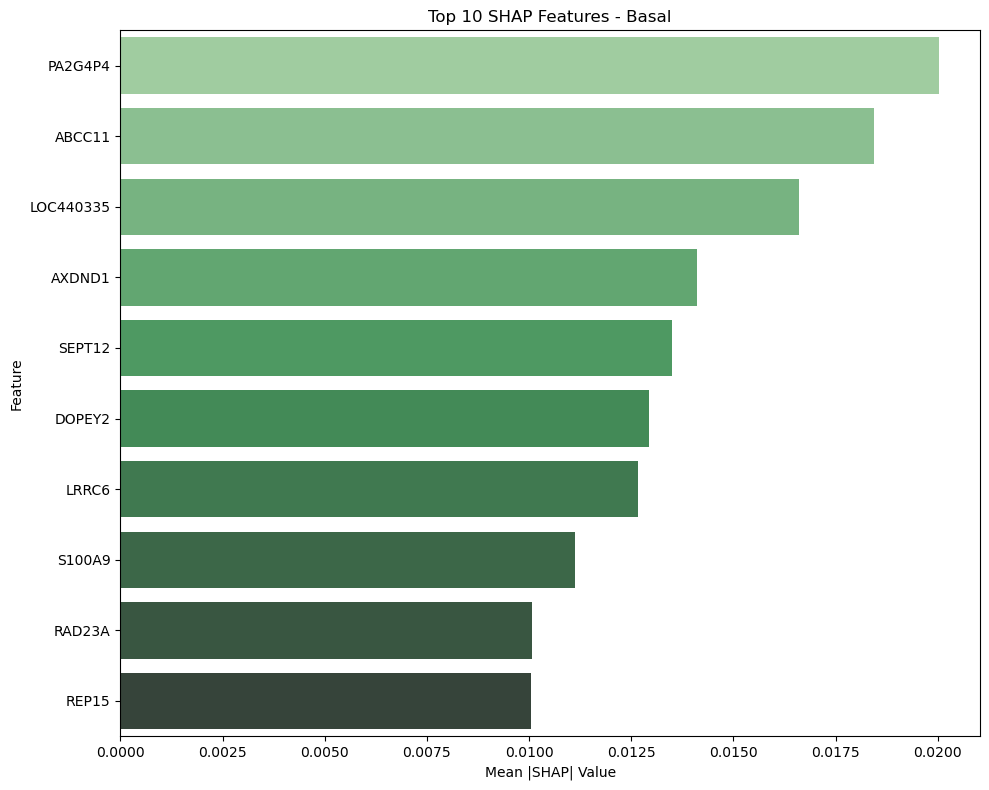


Subtype 2: Her2
    Feature  MeanAbsSHAP
6    AXDND1     0.017297
37    LRRC6     0.016917
13  PA2G4P4     0.013457
1     PRUNE     0.011755
82   ZNF516     0.011186
11  TBL1XR1     0.009333
50  GLYCAM1     0.009260
81   LGALS9     0.008952
2     LEMD1     0.008643
83   DMRTC2     0.008586


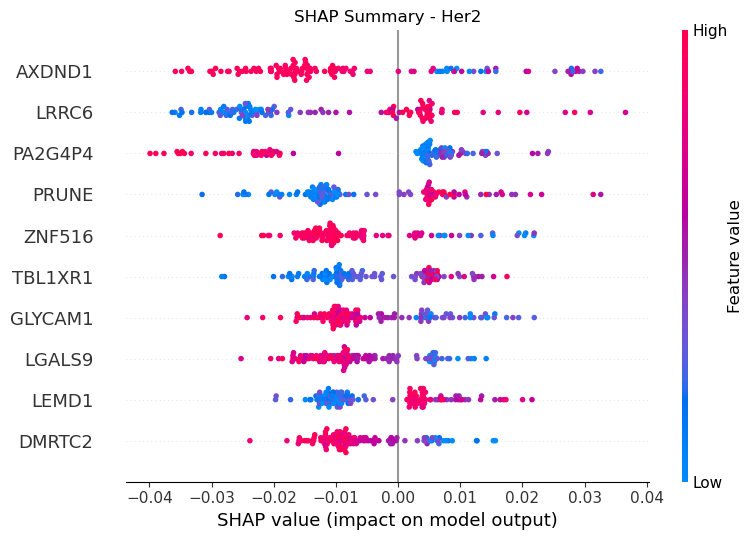

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_2892\3761685964.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


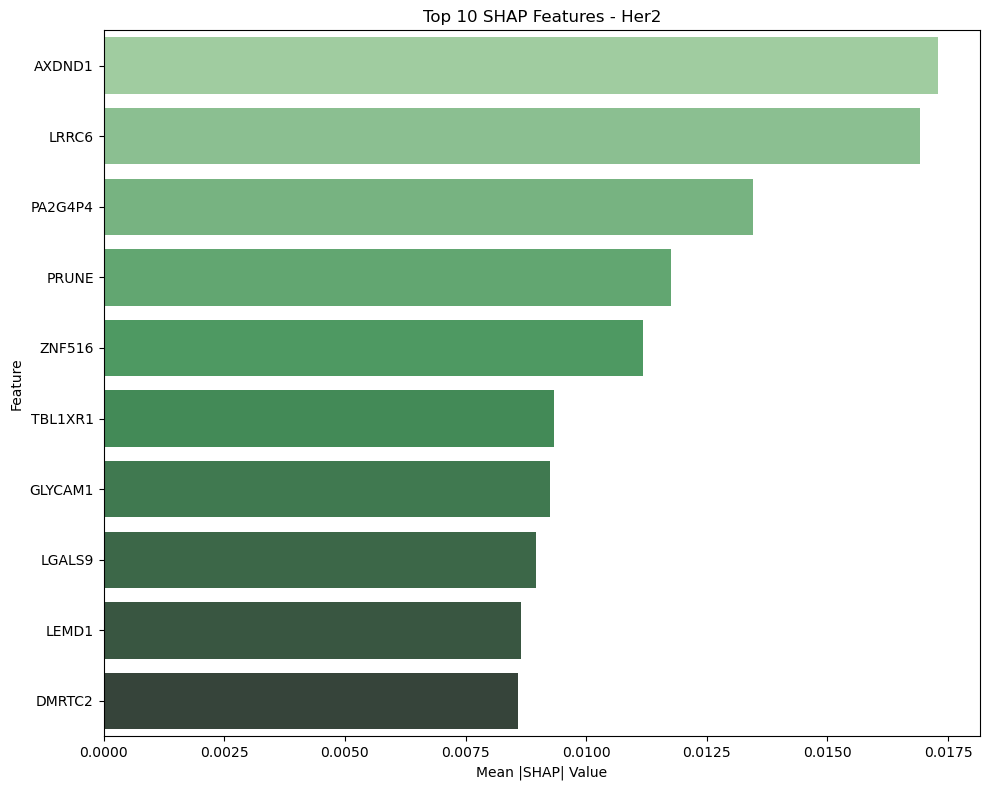


Subtype 3: LumA
      Feature  MeanAbsSHAP
55    MIR1178     0.019570
6      AXDND1     0.019342
48     ZCCHC8     0.017419
37      LRRC6     0.015320
56        CIT     0.015181
70     ABCC11     0.013270
5      S100A9     0.011959
13    PA2G4P4     0.010908
71  LOC440335     0.010829
35     OSGIN2     0.010518


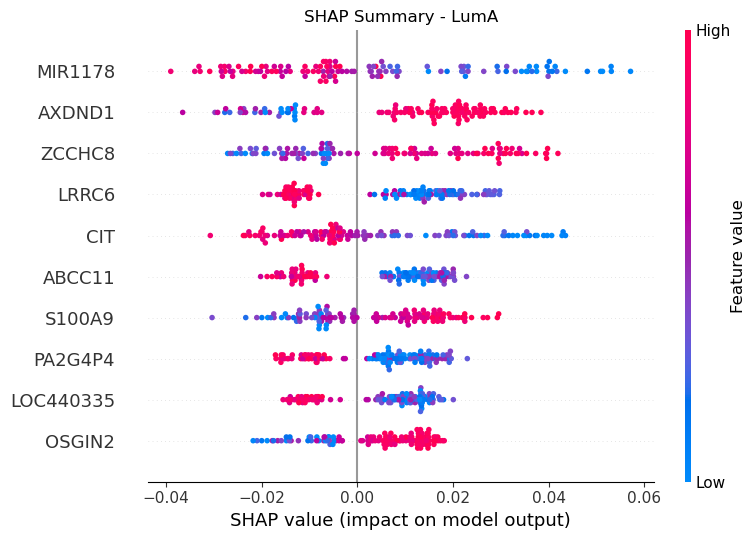

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_2892\3761685964.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


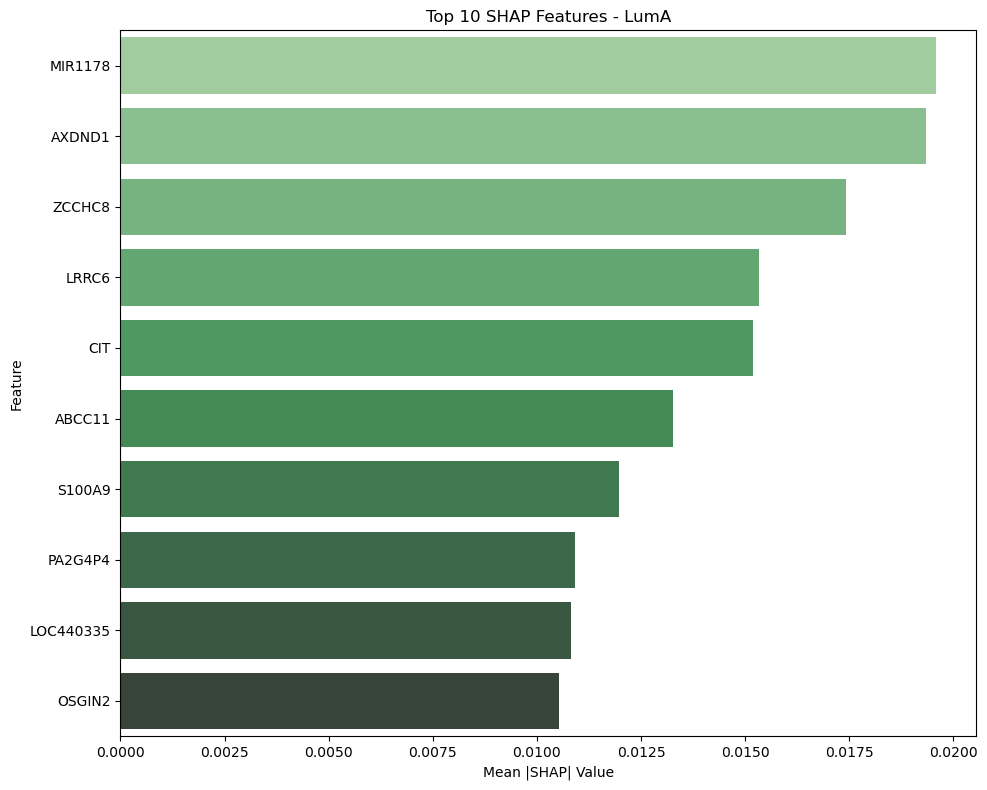


Subtype 4: LumB
      Feature  MeanAbsSHAP
37      LRRC6     0.021677
55    MIR1178     0.016457
48     ZCCHC8     0.014356
13    PA2G4P4     0.013375
56        CIT     0.012341
99       SUN2     0.010931
70     ABCC11     0.010337
1       PRUNE     0.010282
71  LOC440335     0.010092
2       LEMD1     0.008672


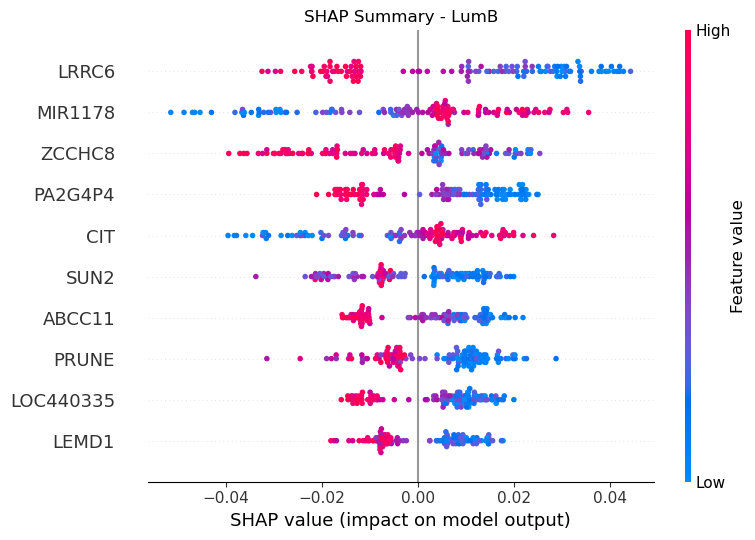

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_2892\3761685964.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


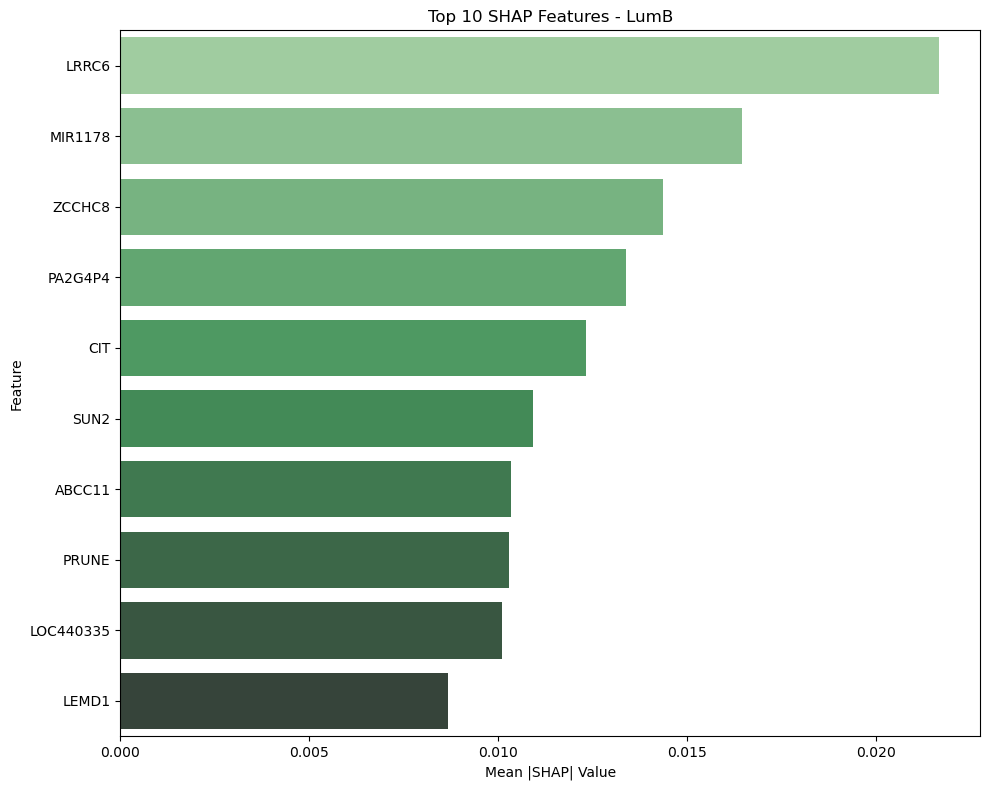


Subtype 5: Normal
      Feature  MeanAbsSHAP
13    PA2G4P4     0.017677
99       SUN2     0.013372
70     ABCC11     0.013074
71  LOC440335     0.010418
20    PCDHGA5     0.010155
22    PCDHGB2     0.009911
57      REP15     0.009901
49   ARHGEF25     0.009739
74    CASKIN2     0.008601
6      AXDND1     0.008454


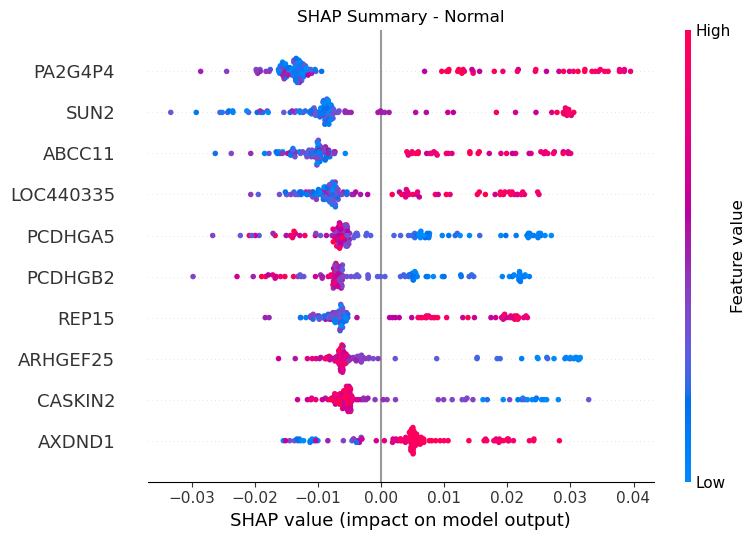

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_2892\3761685964.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


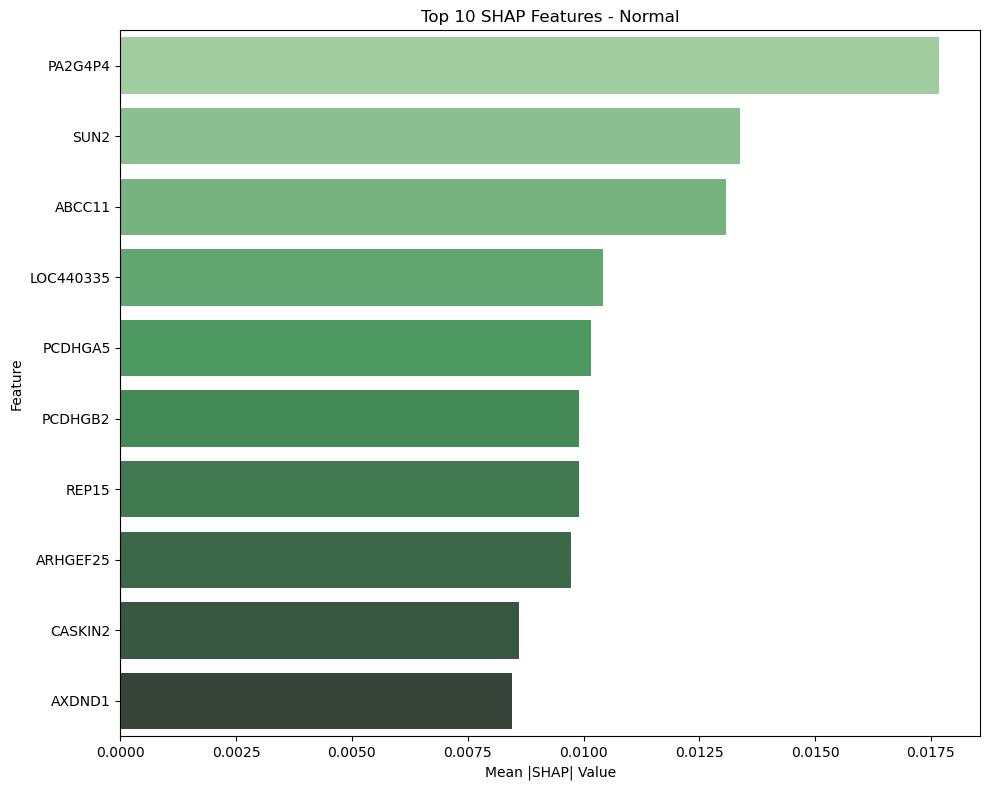


SHAP analysis complete — both overall and per-subtype results generated.


In [6]:
# --- Choose your model ---
best_model_rfe = joblib.load("PKL/RF_TCGA_IP_SMOTE_RFE.pkl")
pipeline_model = best_model_rfe  # or best_model_no_rfe

# --- Extract components ---
rfe = pipeline_model.named_steps['rfe']
rf_model = pipeline_model.named_steps['rf']

# --- Prepare data ---
selected_mask = rfe.support_  # which features RFE kept
selected_features = np.array(X_test.columns)[selected_mask]

# Scale test set
X_test_selected = X_test.values[:, selected_mask]

# --- Create SHAP explainer ---
print("\nCalculating SHAP values...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_selected)

# Handle multi-class output
if isinstance(shap_values, list):  # one array per class
    shap_values = np.stack(shap_values, axis=2)  # shape: (samples, features, classes)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Selected features: {len(selected_features)}")

# ====================================================
# 1. OVERALL (across all classes)
# ====================================================
mean_abs_shap_anywhere = np.abs(shap_values).mean(axis=0).max(axis=1)

shap_importances_overall = pd.DataFrame({
    "Feature": selected_features,
    "MeanAbsSHAP_MaxAcrossSubtypes": mean_abs_shap_anywhere
}).sort_values(by="MeanAbsSHAP_MaxAcrossSubtypes", ascending=False)

print("\n=== Overall Top 10 Features ===")
print(shap_importances_overall.head(10))

# Bar plot
plt.figure(figsize=(10, 8))
sns.barplot(
    data=shap_importances_overall.head(10),
    x="MeanAbsSHAP_MaxAcrossSubtypes",
    y="Feature",
    palette="Greens_d"
)
plt.title("Top 10 SHAP Features Influential in Any Subtype")
plt.xlabel("Mean |SHAP| Value (Max Across Subtypes)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Overall SHAP summary
shap_values_overall = np.abs(shap_values).max(axis=2)  # max per sample across classes
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_overall, X_test_selected,
    feature_names=selected_features,
    max_display=20, show=False
)
plt.title("Overall SHAP Summary")
plt.tight_layout()
plt.show()

# ====================================================
# 2. PER-CLASS (each subtype separately)
# ====================================================
class_names = rf_model.classes_
for class_idx, class_name in enumerate(class_names):
    print(f"\n{'='*50}")
    print(f"Subtype {class_idx + 1}: {class_name}")
    
    shap_values_class = shap_values[:, :, class_idx]
    class_mean_abs_shap = np.abs(shap_values_class).mean(axis=0)
    
    shap_importances_class = pd.DataFrame({
        "Feature": selected_features,
        "MeanAbsSHAP": class_mean_abs_shap
    }).sort_values(by="MeanAbsSHAP", ascending=False)
    
    print(shap_importances_class.head(10))
    
    # SHAP summary plot per class
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values_class, X_test_selected,
        feature_names=selected_features,
        max_display=10, show=False
    )
    plt.title(f"SHAP Summary - {class_name}")
    plt.tight_layout()
    plt.show()
    
    # Bar plot top 10 per class
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=shap_importances_class.head(10),
        x="MeanAbsSHAP",
        y="Feature",
        palette="Greens_d"
    )
    plt.title(f"Top 10 SHAP Features - {class_name}")
    plt.xlabel("Mean |SHAP| Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

print("\nSHAP analysis complete — both overall and per-subtype results generated.")